<a href="https://colab.research.google.com/github/241b218-cpu/Sahil-APS-LAB/blob/main/Lab_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Minimum Cost Spanning Tree
Problem Description:
A spanning tree of a graph can be defined as a graph with minimal set of edges that connect all vertices. A minimum spanning tree of a graph is a spanning tree of the graph with least weight (where the weight is computed by adding the weights of all the edges in the spanning tree). In general, a graph can have multiple minimum spanning trees. The problem is to find a minimum spanning tree of a graph.

This implementation uses a dictionary to represent the weighted graph, where the vertices are keys, and the values are dictionaries containing their adjacent vertices and their weights.

Please note that this implementation assumes that the input graph is connected and weighted.

First, let's create a simple graph to demonstrate Prim's algorithm:

In [8]:
graph = {
    "A": {"B": 10, "C": 15, "D": 20},
    "B": {"A": 10, "C": 12},
    "C": {"A": 15, "B": 12, "D": 18},
    "D": {"A": 20, "C": 18},
}


Now, let's implement Prim's algorithm:

Now, let's run the Prim's algorithm on the example graph:
Keep in mind that this example uses a simple representation of a graph, but for more complex cases, you might want to use a library such as NetworkX to represent and manipulate graphs.

In [7]:
mst, min_weight = prim_algorithm(graph)
print("Minimum Spanning Tree: ", mst)
print("Minimum Weight: ", min_weight)

Minimum Spanning Tree:  {'A': [('B', 10)], 'B': [('A', 10), ('C', 12)], 'C': [('B', 12), ('D', 18)], 'D': [('C', 18)]}
Minimum Weight:  40


Take Differnt example of input graph as discussed in lecture slide and use above code to verify the output

Edges in MST with weights:
A - B : 2
B - D : 4
B - C : 1
C - E : 6
Total weight of MST: 13.0


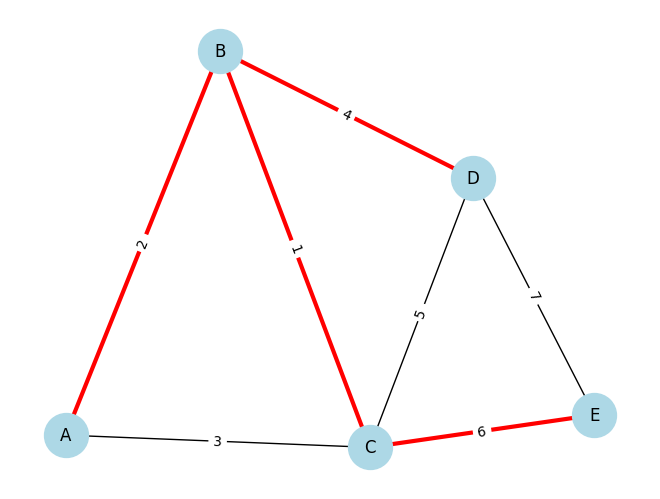

In [10]:
# your sample input of graph
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    "A": {"B": 2, "C": 3},
    "B": {"A": 2, "C": 1, "D": 4},
    "C": {"A": 3, "B": 1, "D": 5, "E": 6},
    "D": {"B": 4, "C": 5, "E": 7},
    "E": {"C": 6, "D": 7}
}

G = nx.Graph()
for u, neighbors in graph.items():
    for v, w in neighbors.items():
        G.add_edge(u, v, weight=w)
mst = nx.minimum_spanning_tree(G, algorithm='prim')

print("Edges in MST with weights:")
for u, v, w in mst.edges(data='weight'):
    print(f"{u} - {v} : {w}")

total_weight = mst.size(weight='weight')
print("Total weight of MST:", total_weight)

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1000)
nx.draw_networkx_edges(G, pos, edgelist=mst.edges(), width=3, edge_color='red')
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()

Edges in MST with weights:
A - B : 2
B - D : 4
B - C : 1
C - E : 6
Total weight of MST: 13.0


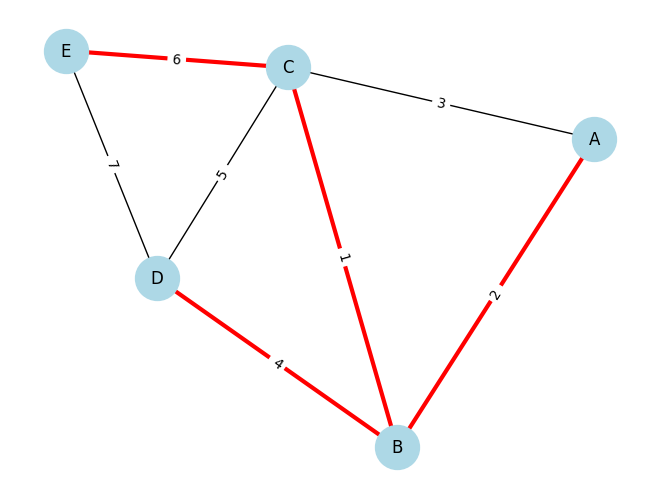

In [11]:
#run prims algorithm for sample input
import networkx as nx
import matplotlib.pyplot as plt

# Sample input graph
graph = {
    "A": {"B": 2, "C": 3},
    "B": {"A": 2, "C": 1, "D": 4},
    "C": {"A": 3, "B": 1, "D": 5, "E": 6},
    "D": {"B": 4, "C": 5, "E": 7},
    "E": {"C": 6, "D": 7}
}
G = nx.Graph()
for u, neighbors in graph.items():
    for v, w in neighbors.items():
        G.add_edge(u, v, weight=w)
mst = nx.minimum_spanning_tree(G, algorithm='prim')

print("Edges in MST with weights:")
for u, v, w in mst.edges(data='weight'):
    print(f"{u} - {v} : {w}")

total_weight = mst.size(weight='weight')
print("Total weight of MST:", total_weight)

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1000)
nx.draw_networkx_edges(G, pos, edgelist=mst.edges(), width=3, edge_color='red')
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()

Use same apporach for Kruskal's algorithm

In [19]:
class DSU:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, i):
        if self.parent[i] == i:
            return i
        self.parent[i] = self.find(self.parent[i])
        return self.parent[i]
    def union(self, i, j):
        root_i = self.find(i)
        root_j = self.find(j)
        if root_i != root_j:
            if self.rank[root_i] < self.rank[root_j]:
                self.parent[root_i] = root_j
            elif self.rank[root_i] > self.rank[root_j]:
                self.parent[root_j] = root_i
            else:
                self.parent[root_j] = root_i
                self.rank[root_i] += 1
            return True
        return False
def kruskal_algorithm(graph):
    edges = []
    nodes = list(graph.keys())
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    for u in graph:
        for v, weight in graph[u].items():
            if node_to_idx[u] < node_to_idx[v]:
                edges.append((weight, u, v))
    edges.sort()

    num_nodes = len(nodes)
    dsu = DSU(num_nodes)
    mst = []
    min_weight = 0

    for weight, u, v in edges:
        if dsu.union(node_to_idx[u], node_to_idx[v]):
            mst.append((u, v, weight))
            min_weight += weight
            if len(mst) == num_nodes - 1:
                break

    return mst, min_weight
